# Vietnamese Food Review Classification with RNN, GRU, and LSTM

This notebook builds a complete **Many-to-One text classification pipeline** for the Kaggle dataset [Vietnamese Sentiment Analysis – Food Reviews](https://www.kaggle.com/datasets/guutran/vietnamese-sentiment-analysis-food-reviews).

It is designed for **Google Colab** and runs sequentially without manual path editing. The workflow downloads and inspects the dataset, detects the text and label columns, preserves Vietnamese Unicode, preprocesses text, builds a training-only vocabulary, trains a configurable recurrent model, and evaluates it with standard multiclass metrics.


## 1. Install and Import Libraries

Colab already includes most dependencies. The first cell installs the Kaggle client quietly so the notebook can download the dataset directly.


In [ ]:
!pip -q install kagglehub


In [1]:
import json
import os
import random
import re
import shutil
import unicodedata
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


## 2. Configuration

Change `MODEL_TYPE` to `"RNN"`, `"GRU"`, or `"LSTM"` to select the recurrent architecture. The default settings are intentionally modest for Colab and training is capped at 10 epochs.


In [2]:
SEED = 42
DATASET_SLUG = "guutran/vietnamese-sentiment-analysis-food-reviews"

BASE_DIR = Path("./vietnamese_food_reviews") if not Path("/content").exists() else Path("/content/vietnamese_food_reviews")
DOWNLOAD_DIR = BASE_DIR / "download"
EXTRACT_DIR = BASE_DIR / "data"
CHECKPOINT_PATH = BASE_DIR / "best_text_classifier.pt"

# Data configuration.
TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15
MAX_VOCAB_SIZE = 30000
MIN_TOKEN_FREQUENCY = 1
MAX_SEQUENCE_LENGTH = 160
# Limit the number of cleaned examples for a quick run; use None for all data.
SAMPLE_LIMIT = None

# Model configuration: choose "RNN", "GRU", or "LSTM".
MODEL_TYPE = "LSTM"
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.30
BIDIRECTIONAL = False

# Training configuration.
BATCH_SIZE = 64
EPOCHS = 10  # Must remain at most 10 for this exercise.
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0
EARLY_STOPPING_PATIENCE = 3
# Keep data loading in the notebook process to avoid Colab worker crashes.
NUM_WORKERS = 0

assert MODEL_TYPE.upper() in {"RNN", "GRU", "LSTM"}
assert 1 <= EPOCHS <= 10
assert SAMPLE_LIMIT is None or (isinstance(SAMPLE_LIMIT, int) and SAMPLE_LIMIT > 0)
assert NUM_WORKERS == 0


## 3. Reproducibility and Device

All random generators are seeded. CUDA is selected automatically when a GPU runtime is available.


In [3]:
def set_seed(seed: int = SEED) -> None:
    # Fix Python, NumPy, and PyTorch randomness.
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Prefer deterministic CUDA behavior when supported.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        pass


set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.13.0+cpu
Using device: cpu


## 4. Download and Extract the Dataset

The Kaggle CLI downloads this public dataset archive without requiring a `kaggle.json` upload. All ZIP archives are extracted recursively, so nested archives are handled automatically.


In [9]:
import kagglehub

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

try:
    downloaded_path = kagglehub.dataset_download(DATASET_SLUG)
    print(f"Downloaded via kagglehub: {downloaded_path}")
    for item in Path(downloaded_path).rglob("*"):
        if item.is_file():
            target = EXTRACT_DIR / item.name
            if not target.exists():
                shutil.copy2(item, target)
except Exception as exc:
    print(f"kagglehub info: {exc}")
    if not list(DOWNLOAD_DIR.glob("*.zip")):
        os.system(f'kaggle datasets download -d {DATASET_SLUG} -p "{DOWNLOAD_DIR}"')

def extract_zip_archives(source_dir: Path, destination_dir: Path) -> None:
    """Extract every ZIP archive, including archives discovered after extraction."""
    processed = set()
    while True:
        archives = [
            path for path in list(source_dir.rglob("*.zip")) + list(destination_dir.rglob("*.zip"))
            if path.resolve() not in processed
        ]
        if not archives:
            break
        for archive_path in archives:
            print(f"Extracting: {archive_path.name}")
            with zipfile.ZipFile(archive_path, "r") as archive:
                archive.extractall(destination_dir)
            processed.add(archive_path.resolve())


extract_zip_archives(DOWNLOAD_DIR, EXTRACT_DIR)
all_files = sorted(path for path in EXTRACT_DIR.rglob("*") if path.is_file())
print(f"Extracted {len(all_files)} file(s):")
for path in all_files:
    print(f" - {path.relative_to(EXTRACT_DIR)} ({path.stat().st_size:,} bytes)")


Downloaded via kagglehub: C:\Users\aaa\.cache\kagglehub\datasets\guutran\vietnamese-sentiment-analysis-food-reviews\versions\2
Extracted 3 file(s):
 - vietnamese-stopwords-dash.txt (20,475 bytes)
 - vsa_food_rv_test.csv (5,121,156 bytes)
 - vsa_food_rv_train.csv (11,326,394 bytes)


## 5. Inspect All Tabular Files and Columns

The loader searches recursively for CSV, TSV, TXT, JSON, JSONL, Excel, and Parquet files. It tries common Unicode encodings and multiple delimiters while keeping Vietnamese text intact. Every readable table and its columns are displayed before selection.


In [10]:
SUPPORTED_SUFFIXES = {".csv", ".tsv", ".txt", ".json", ".jsonl", ".xlsx", ".xls", ".parquet"}


def read_text_table(path: Path) -> pd.DataFrame:
    """Read a delimited text table with Unicode-safe encoding fallbacks."""
    separators = ["\t"] if path.suffix.lower() == ".tsv" else [None, ",", "\t", ";", "|"]
    errors = []
    for encoding in ("utf-8-sig", "utf-8", "cp1258", "latin-1"):
        for separator in separators:
            try:
                frame = pd.read_csv(
                    path,
                    sep=separator,
                    engine="python",
                    encoding=encoding,
                    on_bad_lines="skip",
                )
                if frame.shape[1] >= 2 and len(frame) > 0:
                    return frame
            except Exception as exc:
                errors.append(f"{encoding}/{separator}: {exc}")
    raise ValueError(f"Could not parse {path.name}. Last errors: {errors[-3:]}")


def read_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix in {".csv", ".tsv", ".txt"}:
        return read_text_table(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".jsonl":
        return pd.read_json(path, lines=True)
    if suffix == ".json":
        try:
            return pd.read_json(path)
        except ValueError:
            return pd.read_json(path, lines=True)
    raise ValueError(f"Unsupported file type: {suffix}")


tabular_files = [path for path in all_files if path.suffix.lower() in SUPPORTED_SUFFIXES]
if not tabular_files:
    raise FileNotFoundError("No supported tabular files were found after extraction.")

loaded_tables = {}
for path in tabular_files:
    try:
        frame = read_table(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        loaded_tables[path] = frame
        print("\n" + "=" * 100)
        print(f"FILE: {path.relative_to(EXTRACT_DIR)} | shape={frame.shape}")
        print("COLUMNS:", list(frame.columns))
        display(frame.head(3))
        print(frame.dtypes.to_string())
    except Exception as exc:
        print(f"Skipped {path.relative_to(EXTRACT_DIR)}: {exc}")

if not loaded_tables:
    raise RuntimeError("Files were found, but none could be parsed as a table.")



FILE: vietnamese-stopwords-dash.txt | shape=(1927, 2)
COLUMNS: ['a_', 'ô']


,a_,ô
0,a_ha,None
1,ai,None
2,ai_ai,None


a_    object
ô     object

FILE: vsa_food_rv_test.csv | shape=(9605, 3)
COLUMNS: ['Co', 'Unnamed: 1', 'ent']


,Co,Unnamed: 1,ent
0,Trà táo 35k\nCookie socola 38k \nNước ở đây bì...,None,None
1,Hôm rồi trung tâm mình tổ chức noel party ở đâ...,None,None
2,Thịt gà của quán là nhất đấy. Đi ăn gọi liền 4...,None,None


Co            object
Unnamed: 1    object
ent           object

FILE: vsa_food_rv_train.csv | shape=(22847, 2)
COLUMNS: ['Comment', 'Rating']


,Comment,Rating
0,Món ăn cực tệ,0.0
1,Mình thấy mọi người review tích cực nhưng thực...,0.0
2,Chắc với sinh viên thì ai cũng quen thuộc với ...,1.0


Comment     object
Rating     float64


## 6. Automatically Detect Text and Sentiment Columns

Column detection combines name hints with data characteristics:

- A text column receives a high score when its name resembles `review`, `comment`, `text`, or Vietnamese equivalents and its values contain relatively long strings.
- A label column receives a high score when its name resembles `label`, `sentiment`, `rating`, or Vietnamese equivalents and it has a small number of distinct values.

The best valid table/column combination is selected automatically and the decision is printed for transparency.


In [8]:
TEXT_HINTS = (
    "text", "review", "comment", "content", "sentence", "feedback",
    "description", "commentary", "noi_dung", "noidung", "binh_luan", "binhluan",
)
LABEL_HINTS = (
    "label", "sentiment", "class", "target", "rating", "star", "score",
    "polarity", "emotion", "nhan", "cam_xuc", "camxuc", "danh_gia", "danhgia",
)


def normalized_name(name: str) -> str:
    """Normalize a column name for robust hint matching only."""
    value = unicodedata.normalize("NFD", str(name).lower())
    value = "".join(char for char in value if unicodedata.category(char) != "Mn")
    return re.sub(r"[^a-z0-9]+", "_", value).strip("_")


def text_column_score(series: pd.Series, name: str) -> float:
    values = series.dropna().astype(str)
    if values.empty:
        return float("-inf")
    sample = values.head(3000)
    avg_length = sample.str.len().mean()
    unique_ratio = sample.nunique() / max(1, len(sample))
    name_score = 10.0 if any(hint in normalized_name(name) for hint in TEXT_HINTS) else 0.0
    return name_score + min(avg_length / 20.0, 8.0) + 2.0 * unique_ratio


def label_column_score(series: pd.Series, name: str) -> float:
    values = series.dropna()
    if values.empty:
        return float("-inf")
    unique_count = values.astype(str).nunique()
    unique_ratio = unique_count / max(1, len(values))
    if unique_count < 2 or unique_count > max(100, int(0.20 * len(values))):
        return float("-inf")
    name_score = 10.0 if any(hint in normalized_name(name) for hint in LABEL_HINTS) else 0.0
    cardinality_score = 6.0 if unique_count <= 10 else max(0.0, 6.0 - unique_count / 10.0)
    return name_score + cardinality_score - unique_ratio


def detect_schema(tables: dict) -> tuple:
    candidates = []
    for path, frame in tables.items():
        for text_column in frame.columns:
            text_score = text_column_score(frame[text_column], text_column)
            for label_column in frame.columns:
                if text_column == label_column:
                    continue
                label_score = label_column_score(frame[label_column], label_column)
                score = text_score + label_score + min(np.log10(len(frame) + 1), 5.0)
                candidates.append((score, path, text_column, label_column))
    valid_candidates = [item for item in candidates if np.isfinite(item[0])]
    if not valid_candidates:
        raise ValueError("Could not automatically detect compatible text and label columns.")
    return max(valid_candidates, key=lambda item: item[0])


schema_score, selected_path, text_column, label_column = detect_schema(loaded_tables)
raw_df = loaded_tables[selected_path].copy()

print(f"Selected file: {selected_path.relative_to(EXTRACT_DIR)}")
print(f"Detected text column: {text_column!r}")
print(f"Detected label column: {label_column!r}")
print(f"Detection score: {schema_score:.3f}")
print("\nRaw label distribution:")
display(raw_df[label_column].value_counts(dropna=False).to_frame("count"))


Selected file: vsa_food_rv_train.csv
Detected text column: 'Comment'
Detected label column: 'Rating'
Detection score: 40.343

Raw label distribution:


,count
Rating,
1.0,17351
0.0,5490
NaN,6


## 7. Clean Rows and Encode Labels

Only missing/empty examples and exact duplicate text-label pairs are removed. Vietnamese content is normalized to Unicode NFC, which preserves all diacritics while ensuring a consistent representation. Original text is retained for prediction displays.


In [11]:
df = raw_df[[text_column, label_column]].copy()
df.columns = ["text", "label_original"]
df = df.dropna(subset=["text", "label_original"])

# Preserve Vietnamese characters and normalize their Unicode representation.
df["text"] = df["text"].astype(str).map(lambda value: unicodedata.normalize("NFC", value).strip())
df["label_original"] = df["label_original"].astype(str).str.strip()
df = df[(df["text"] != "") & (df["label_original"] != "")]
df = df.drop_duplicates(subset=["text", "label_original"]).reset_index(drop=True)

# Stable sorting makes the numeric mapping reproducible.
class_names = sorted(df["label_original"].unique().tolist())
label_to_id = {label: index for index, label in enumerate(class_names)}
id_to_label = {index: label for label, index in label_to_id.items()}
df["label"] = df["label_original"].map(label_to_id).astype(int)

# Optionally train/evaluate on a reproducible subset of the cleaned data.
if SAMPLE_LIMIT is not None and SAMPLE_LIMIT < len(df):
    if SAMPLE_LIMIT < len(class_names):
        raise ValueError(
            f"SAMPLE_LIMIT must be at least the number of classes ({len(class_names)})."
        )
    stratify_labels = df["label"] if df["label"].value_counts().min() >= 2 else None
    df, _ = train_test_split(
        df,
        train_size=SAMPLE_LIMIT,
        random_state=SEED,
        stratify=stratify_labels,
    )
    df = df.reset_index(drop=True)
    print(f"SAMPLE_LIMIT active: using {len(df):,} cleaned examples.")
elif SAMPLE_LIMIT is not None:
    print(f"SAMPLE_LIMIT={SAMPLE_LIMIT:,} is not below the dataset size; using all data.")

if len(class_names) < 2:
    raise ValueError("At least two sentiment classes are required.")

print(f"Usable examples: {len(df):,}")
print(f"Number of classes: {len(class_names)}")
print("Label mapping:", label_to_id)
display(df.head())
display(df["label_original"].value_counts().to_frame("count"))


Usable examples: 12,927
Number of classes: 2
Label mapping: {'0.0': 0, '1.0': 1}


,text,label_original,label
0,Món ăn cực tệ,0.0,0
1,Mình thấy mọi người review tích cực nhưng thực...,0.0,0
2,Chắc với sinh viên thì ai cũng quen thuộc với ...,1.0,1
3,Nhiều hôm thèm lẩu riêu mà chỉ có một mình thì...,1.0,1
4,Không gian sạch sẽ.quán mới lên ra món hơi chậ...,1.0,1


,count
label_original,
1.0,9636
0.0,3291


## 8. Vietnamese Text Preprocessing and Tokenization

Preprocessing performs exactly the requested operations:

1. NFC Unicode normalization and lowercase conversion.
2. URL removal.
3. Whitespace normalization.
4. Unicode-aware tokenization.

The tokenizer keeps Vietnamese letters with their diacritics, words, numbers, and common punctuation. The original text in `df["text"]` is never overwritten.


In [12]:
URL_PATTERN = re.compile(r"(?:https?://|www\.)\S+", flags=re.IGNORECASE)
TOKEN_PATTERN = re.compile(r"[^\W_]+(?:['’][^\W_]+)*|[^\w\s]", flags=re.UNICODE)


def normalize_text(text: str) -> str:
    """Lowercase text, remove URLs, and normalize Unicode and whitespace."""
    text = unicodedata.normalize("NFC", str(text)).lower()
    text = URL_PATTERN.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text: str) -> list[str]:
    """Tokenize Vietnamese text without removing diacritics."""
    return TOKEN_PATTERN.findall(normalize_text(text))


for sample_text in df["text"].head(3):
    print("Original:", sample_text)
    print("Normalized:", normalize_text(sample_text))
    print("Tokens:", tokenize(sample_text))
    print("-" * 100)


Original: Món ăn cực tệ
Normalized: món ăn cực tệ
Tokens: ['món', 'ăn', 'cực', 'tệ']
----------------------------------------------------------------------------------------------------
Original: Mình thấy mọi người review tích cực nhưng thực sự mình không thấy lẩu ở đây giống review. Lẩu đắt và chán thực sự. Never come back!
Normalized: mình thấy mọi người review tích cực nhưng thực sự mình không thấy lẩu ở đây giống review. lẩu đắt và chán thực sự. never come back!
Tokens: ['mình', 'thấy', 'mọi', 'người', 'review', 'tích', 'cực', 'nhưng', 'thực', 'sự', 'mình', 'không', 'thấy', 'lẩu', 'ở', 'đây', 'giống', 'review', '.', 'lẩu', 'đắt', 'và', 'chán', 'thực', 'sự', '.', 'never', 'come', 'back', '!']
----------------------------------------------------------------------------------------------------
Original: Chắc với sinh viên thì ai cũng quen thuộc với lẩu Nguyệt. Cứ có dịp gì tụ tập đông đông là nhóm mình lại qua đây ăn. Vừa ngon vừa rẻ. Quán thì phải kéo dài từ vỉa hè đến cả trong ngõ 

## 9. Stratified Train, Validation, and Test Splits

The helper uses stratification only when every class has enough examples for the requested split. If stratification is mathematically impossible, it falls back to a seeded random split and prints a warning.


In [13]:
def can_stratify(labels: pd.Series, test_fraction: float) -> bool:
    counts = labels.value_counts()
    test_count = int(np.ceil(len(labels) * test_fraction))
    train_count = len(labels) - test_count
    return (
        len(counts) > 1
        and counts.min() >= 2
        and test_count >= len(counts)
        and train_count >= len(counts)
    )


def safe_split(frame: pd.DataFrame, test_size: float, seed: int, split_name: str):
    stratify_values = frame["label"] if can_stratify(frame["label"], test_size) else None
    if stratify_values is None:
        print(f"Warning: {split_name} split cannot be stratified; using a seeded random split.")
    return train_test_split(
        frame,
        test_size=test_size,
        random_state=seed,
        stratify=stratify_values,
    )


train_val_df, test_df = safe_split(df, TEST_SIZE, SEED, "test")
relative_val_size = VALIDATION_SIZE / (1.0 - TEST_SIZE)
train_df, val_df = safe_split(train_val_df, relative_val_size, SEED, "validation")

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):,} ({len(train_df) / len(df):.1%})")
print(f"Validation: {len(val_df):,} ({len(val_df) / len(df):.1%})")
print(f"Test: {len(test_df):,} ({len(test_df) / len(df):.1%})")

split_distribution = pd.concat(
    {
        "train": train_df["label_original"].value_counts(normalize=True),
        "validation": val_df["label_original"].value_counts(normalize=True),
        "test": test_df["label_original"].value_counts(normalize=True),
    },
    axis=1,
).fillna(0)
display(split_distribution)


Train: 9,048 (70.0%)
Validation: 1,939 (15.0%)
Test: 1,940 (15.0%)


,train,validation,test
label_original,,,
1.0,0.745469,0.745229,0.745361
0.0,0.254531,0.254771,0.254639


## 10. Build the Vocabulary from the Training Set Only

This prevents information leakage from validation and test text. `<PAD>` has index 0 and `<UNK>` handles unseen tokens.


In [14]:
token_counter = Counter()
for text in tqdm(train_df["text"], desc="Building vocabulary"):
    token_counter.update(tokenize(text))

special_tokens = ["<PAD>", "<UNK>"]
vocabulary_tokens = [
    token
    for token, frequency in token_counter.most_common()
    if frequency >= MIN_TOKEN_FREQUENCY
][: MAX_VOCAB_SIZE - len(special_tokens)]

id_to_token = special_tokens + vocabulary_tokens
token_to_id = {token: index for index, token in enumerate(id_to_token)}
PAD_ID = token_to_id["<PAD>"]
UNK_ID = token_to_id["<UNK>"]
VOCAB_SIZE = len(id_to_token)

print(f"Vocabulary size: {VOCAB_SIZE:,}")
print(f"PAD_ID={PAD_ID}, UNK_ID={UNK_ID}")
print("Most common training tokens:", token_counter.most_common(20))


Building vocabulary:   0%|          | 0/9048 [00:00<?, ?it/s]

Vocabulary size: 11,303
PAD_ID=0, UNK_ID=1
Most common training tokens: [('.', 37886), (',', 36437), ('ăn', 16475), ('mình', 14286), ('có', 11908), ('là', 10770), ('quán', 9601), ('không', 9158), ('và', 8839), ('thì', 8810), ('ngon', 7543), ('cũng', 6973), (')', 6791), ('rất', 6053), ('ở', 5944), ('nên', 5836), ('nhưng', 5734), ('mà', 5260), ('1', 5256), (':', 5214)]


## 11. Encode, Truncate, and Pad Sequences

Each review is truncated to `MAX_SEQUENCE_LENGTH`. Shorter reviews are padded to a fixed size, and their real length is retained so the recurrent model can ignore padding through `pack_padded_sequence`.


In [15]:
def encode_text(text: str) -> tuple[list[int], int]:
    tokens = tokenize(text)
    token_ids = [token_to_id.get(token, UNK_ID) for token in tokens]

    # Keep at least one token so packed sequences always have positive lengths.
    if not token_ids:
        token_ids = [UNK_ID]

    token_ids = token_ids[:MAX_SEQUENCE_LENGTH]
    sequence_length = len(token_ids)
    token_ids += [PAD_ID] * (MAX_SEQUENCE_LENGTH - sequence_length)
    return token_ids, sequence_length


sample_ids, sample_length = encode_text(train_df.loc[0, "text"])
print("Original text:", train_df.loc[0, "text"])
print("Sequence length:", sample_length)
print("First token IDs:", sample_ids[:25])


Original text: Sợ béo nhưng thèm trà nên đc a nv tư vấn uống trà đào cam xả... Đồ uống ngon, nv nhiệt tình... Tầng 3 4 là quán game tranh thủ lên làm ván luôn quá tiện😂
Sequence length: 44
First token IDs: [638, 401, 18, 411, 91, 17, 144, 708, 584, 509, 658, 66, 91, 563, 852, 1267, 2, 2, 2, 22, 66, 12, 3, 584, 158]


## 12. PyTorch Dataset and DataLoaders

The dataset returns token IDs, the real sequence length, the numeric label, and the row index. The row index connects test predictions back to their untouched original text.


In [16]:
class FoodReviewDataset(Dataset):
    """Encoded Vietnamese food reviews for multiclass classification."""

    def __init__(self, frame: pd.DataFrame) -> None:
        self.frame = frame.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        token_ids, sequence_length = encode_text(self.frame.loc[index, "text"])
        return {
            "input_ids": torch.tensor(token_ids, dtype=torch.long),
            "length": torch.tensor(sequence_length, dtype=torch.long),
            "label": torch.tensor(self.frame.loc[index, "label"], dtype=torch.long),
            "index": torch.tensor(index, dtype=torch.long),
        }


train_dataset = FoodReviewDataset(train_df)
val_dataset = FoodReviewDataset(val_df)
test_dataset = FoodReviewDataset(test_df)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 142
Validation batches: 31
Test batches: 31


## 13. Configurable Many-to-One RNN/GRU/LSTM Classifier

The same classifier supports Vanilla RNN, GRU, and LSTM. Reviews are embedded, packed using their true lengths, processed by the selected recurrent layer, and reduced to the final hidden state before classification.


In [17]:
class RecurrentTextClassifier(nn.Module):
    """Many-to-One classifier backed by a Vanilla RNN, GRU, or LSTM."""

    def __init__(
        self,
        vocabulary_size: int,
        embedding_dim: int,
        hidden_dim: int,
        output_dim: int,
        pad_id: int,
        model_type: str = "LSTM",
        num_layers: int = 1,
        dropout: float = 0.3,
        bidirectional: bool = False,
    ) -> None:
        super().__init__()
        self.model_type = model_type.upper()
        self.num_directions = 2 if bidirectional else 1
        self.embedding = nn.Embedding(vocabulary_size, embedding_dim, padding_idx=pad_id)
        self.embedding_dropout = nn.Dropout(dropout)

        recurrent_classes = {"RNN": nn.RNN, "GRU": nn.GRU, "LSTM": nn.LSTM}
        recurrent_class = recurrent_classes[self.model_type]
        self.recurrent = recurrent_class(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.output_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * self.num_directions, output_dim)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding_dropout(self.embedding(input_ids))
        packed = pack_padded_sequence(
            embedded,
            lengths.detach().cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _packed_output, hidden = self.recurrent(packed)

        # LSTM returns (hidden_state, cell_state); RNN and GRU return hidden_state.
        if self.model_type == "LSTM":
            hidden = hidden[0]

        if self.num_directions == 2:
            final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            final_hidden = hidden[-1]

        return self.classifier(self.output_dropout(final_hidden))


## 14. Initialize the Model

Cross-entropy loss supports any number of detected sentiment classes. AdamW performs optimization and gradient clipping limits unstable recurrent gradients.


In [18]:
model_config = {
    "vocabulary_size": VOCAB_SIZE,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "output_dim": len(class_names),
    "pad_id": PAD_ID,
    "model_type": MODEL_TYPE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "bidirectional": BIDIRECTIONAL,
}

model = RecurrentTextClassifier(**model_config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(model)
print(f"Trainable parameters: {trainable_parameters:,}")


RecurrentTextClassifier(
  (embedding): Embedding(11303, 128, padding_idx=0)
  (embedding_dropout): Dropout(p=0.3, inplace=False)
  (recurrent): LSTM(128, 128, batch_first=True)
  (output_dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)
Trainable parameters: 1,579,138


## 15. Metrics and Epoch Helpers

Accuracy and macro-averaged precision, recall, and F1 treat each class equally. This is important when sentiment classes are imbalanced.


In [19]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }


def run_epoch(model, dataloader, criterion, device, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    all_labels, all_predictions, all_probabilities, all_indices = [], [], [], []

    progress = tqdm(
        dataloader,
        desc="Training" if is_training else "Evaluating",
        leave=False,
    )

    for batch in progress:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        lengths = batch["length"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        all_labels.extend(labels.detach().cpu().tolist())
        all_predictions.extend(predictions.detach().cpu().tolist())
        all_probabilities.extend(probabilities.detach().cpu().numpy())
        all_indices.extend(batch["index"].tolist())
        progress.set_postfix(loss=f"{loss.item():.4f}")

    y_true = np.asarray(all_labels)
    y_pred = np.asarray(all_predictions)
    metrics = compute_metrics(y_true, y_pred)
    average_loss = total_loss / len(dataloader.dataset)
    return average_loss, metrics, y_true, y_pred, np.asarray(all_probabilities), np.asarray(all_indices)


## 16. Train with Early Stopping and Best Checkpoint Saving

Training runs for at most 10 epochs. The checkpoint with the lowest validation loss is saved, and training stops when validation loss does not improve for `EARLY_STOPPING_PATIENCE` consecutive epochs.


In [20]:
history = {"train_loss": [], "val_loss": [], "train_macro_f1": [], "val_macro_f1": []}
best_validation_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_metrics, *_ = run_epoch(
        model, train_loader, criterion, device, optimizer=optimizer
    )
    val_loss, val_metrics, *_ = run_epoch(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_macro_f1"].append(train_metrics["macro_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])

    improved = val_loss < best_validation_loss - 1e-6
    if improved:
        best_validation_loss = val_loss
        epochs_without_improvement = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "model_config": model_config,
                "label_to_id": label_to_id,
                "id_to_label": id_to_label,
                "token_to_id": token_to_id,
                "max_sequence_length": MAX_SEQUENCE_LENGTH,
                "epoch": epoch,
                "validation_loss": val_loss,
            },
            CHECKPOINT_PATH,
        )
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_metrics['accuracy']:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered after epoch {epoch}.")
        break

print(f"Best validation loss: {best_validation_loss:.4f}")
print(f"Best checkpoint: {CHECKPOINT_PATH}")


Training:   0%|          | 0/142 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 01/10 | train_loss=0.5038 | train_acc=0.7656 | train_macro_f1=0.6183 | val_loss=0.4065 | val_acc=0.8561 | val_macro_f1=0.7856


Training:   0%|          | 0/142 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 07/10 | train_loss=0.2169 | train_acc=0.9240 | train_macro_f1=0.8971 | val_loss=0.3321 | val_acc=0.8922 | val_macro_f1=0.8529


Training:   0%|          | 0/142 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 08/10 | train_loss=0.2086 | train_acc=0.9278 | train_macro_f1=0.9019 | val_loss=0.3353 | val_acc=0.8901 | val_macro_f1=0.8418
Early stopping triggered after epoch 8.
Best validation loss: 0.3060
Best checkpoint: \content\vietnamese_food_reviews\best_text_classifier.pt


## 17. Plot Training and Validation Loss


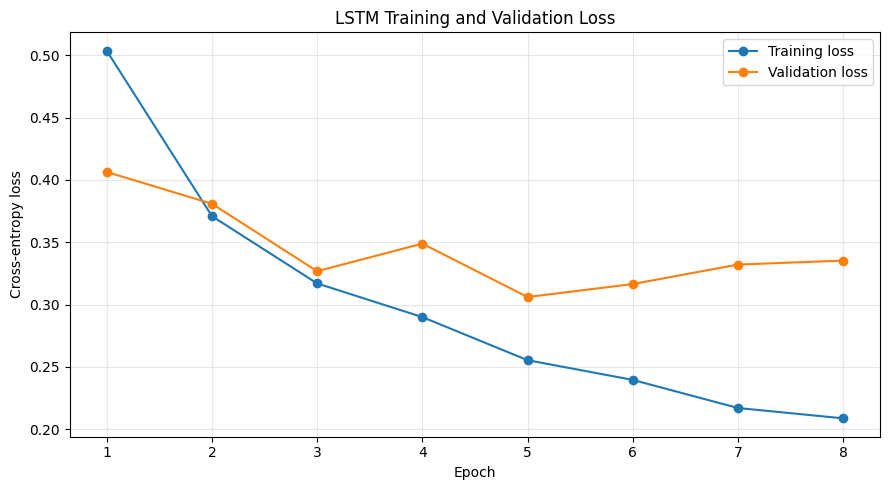

In [21]:
epoch_numbers = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(9, 5))
plt.plot(epoch_numbers, history["train_loss"], marker="o", label="Training loss")
plt.plot(epoch_numbers, history["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title(f"{MODEL_TYPE.upper()} Training and Validation Loss")
plt.xticks(list(epoch_numbers))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 18. Load the Best Checkpoint and Evaluate the Test Set

The final evaluation uses the saved best-validation checkpoint rather than the last epoch.


In [22]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
best_model = RecurrentTextClassifier(**checkpoint["model_config"]).to(device)
best_model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_metrics, y_test, y_pred, y_probability, test_indices = run_epoch(
    best_model,
    test_loader,
    criterion,
    device,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy:        {test_metrics['accuracy']:.4f}")
print(f"Macro Precision: {test_metrics['macro_precision']:.4f}")
print(f"Macro Recall:    {test_metrics['macro_recall']:.4f}")
print(f"Macro-F1:        {test_metrics['macro_f1']:.4f}")

all_label_ids = list(range(len(class_names)))
print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=all_label_ids,
        target_names=[id_to_label[index] for index in all_label_ids],
        digits=4,
        zero_division=0,
    )
)


Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Test loss: 0.2926
Accuracy:        0.8979
Macro Precision: 0.8725
Macro Recall:    0.8529
Macro-F1:        0.8620

Classification report:
              precision    recall  f1-score   support

         0.0     0.8246    0.7611    0.7916       494
         1.0     0.9205    0.9447    0.9324      1446

    accuracy                         0.8979      1940
   macro avg     0.8725    0.8529    0.8620      1940
weighted avg     0.8961    0.8979    0.8966      1940



## 19. Confusion Matrix


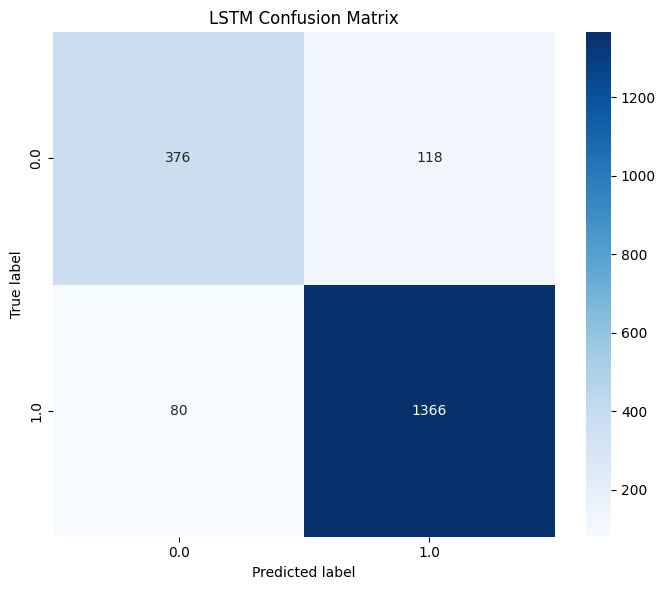

In [23]:
matrix = confusion_matrix(y_test, y_pred, labels=all_label_ids)
plt.figure(figsize=(max(7, len(class_names) * 1.3), max(6, len(class_names))))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id_to_label[index] for index in all_label_ids],
    yticklabels=[id_to_label[index] for index in all_label_ids],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"{MODEL_TYPE.upper()} Confusion Matrix")
plt.tight_layout()
plt.show()


## 20. Display Test Predictions

The table shows at least 10 examples with untouched original Vietnamese text, true label, predicted label, and model confidence.


In [24]:
prediction_rows = []
for position, dataset_index in enumerate(test_indices):
    true_id = int(y_test[position])
    predicted_id = int(y_pred[position])
    prediction_rows.append(
        {
            "original_text": test_df.loc[int(dataset_index), "text"],
            "true_label": id_to_label[true_id],
            "predicted_label": id_to_label[predicted_id],
            "confidence": float(y_probability[position, predicted_id]),
        }
    )

predictions_df = pd.DataFrame(prediction_rows)
display(
    predictions_df.sample(
        n=min(max(10, min(15, len(predictions_df))), len(predictions_df)),
        random_state=SEED,
    ).reset_index(drop=True)
)


,original_text,true_label,predicted_label,confidence
0,Mình chưa uống ở đây bao giờ nên hôm nay rủ mọ...,1.0,1.0,0.984097
1,Được chồng giới thiệu quán khá ngon giá cả lại...,1.0,1.0,0.944770
2,"Cơm mềm, rau xanh và tươi. Giá cả hợp lý . Mìn...",1.0,1.0,0.983302
3,Một tuần ngồi ở Dingtea Lạc Trung cũng phải và...,0.0,1.0,0.985431
4,Ơ thấy sáng cuối tuần ở đây đông lắm mà hong t...,1.0,1.0,0.964634
5,Bánh giò của quán ăn cùng chả ước thì phải nói...,1.0,1.0,0.947170
6,"Quán rộng rãi , trang trí thì đơn giản thôi ạ,...",1.0,1.0,0.984534
7,"Lòng ở đây rất tươi, mắm tôm thơm, cháo cũng n...",1.0,1.0,0.983419
8,Khoan bàn về giá cả và chất lượng món ăn (vì đ...,0.0,0.0,0.947266
9,Cơm ngon,1.0,1.0,0.828806


## 21. Inference for New Vietnamese Sentences

`predict_sentiment` applies the same preprocessing, vocabulary, padding, and truncation used during training. It returns the predicted original label, confidence, and the probability of every class.


In [25]:
@torch.no_grad()
def predict_sentiment(text: str, model=best_model) -> dict:
    """Predict sentiment for one new Vietnamese sentence."""
    model.eval()
    token_ids, sequence_length = encode_text(text)
    input_tensor = torch.tensor([token_ids], dtype=torch.long, device=device)
    length_tensor = torch.tensor([sequence_length], dtype=torch.long, device=device)

    logits = model(input_tensor, length_tensor)
    probabilities = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    predicted_id = int(probabilities.argmax())

    return {
        "text": text,
        "predicted_label": id_to_label[predicted_id],
        "confidence": float(probabilities[predicted_id]),
        "class_probabilities": {
            id_to_label[index]: float(probability)
            for index, probability in enumerate(probabilities)
        },
    }


new_reviews = [
    "Món ăn rất ngon, nhân viên thân thiện và phục vụ nhanh.",
    "Đồ ăn nguội, quá mặn và tôi phải chờ rất lâu.",
    "Quán sạch sẽ nhưng hương vị chỉ ở mức bình thường.",
]

for review in new_reviews:
    result = predict_sentiment(review)
    print(f"Text: {result['text']}")
    print(f"Prediction: {result['predicted_label']}")
    print(f"Confidence: {result['confidence']:.4f}")
    print(f"Probabilities: {result['class_probabilities']}")
    print("-" * 100)


Text: Món ăn rất ngon, nhân viên thân thiện và phục vụ nhanh.
Prediction: 1.0
Confidence: 0.9858
Probabilities: {'0.0': 0.014247390441596508, '1.0': 0.9857526421546936}
----------------------------------------------------------------------------------------------------
Text: Đồ ăn nguội, quá mặn và tôi phải chờ rất lâu.
Prediction: 1.0
Confidence: 0.6228
Probabilities: {'0.0': 0.37722766399383545, '1.0': 0.6227723360061646}
----------------------------------------------------------------------------------------------------
Text: Quán sạch sẽ nhưng hương vị chỉ ở mức bình thường.
Prediction: 1.0
Confidence: 0.9233
Probabilities: {'0.0': 0.076717808842659, '1.0': 0.9232822060585022}
----------------------------------------------------------------------------------------------------


## 22. Visualize Real Test Predictions

The chart below uses actual held-out test reviews. It deliberately includes both
correct and incorrect predictions when errors are available. Bar length is model
confidence and color indicates whether the prediction matches the true label.
The accompanying table keeps the original Vietnamese review text for inspection.

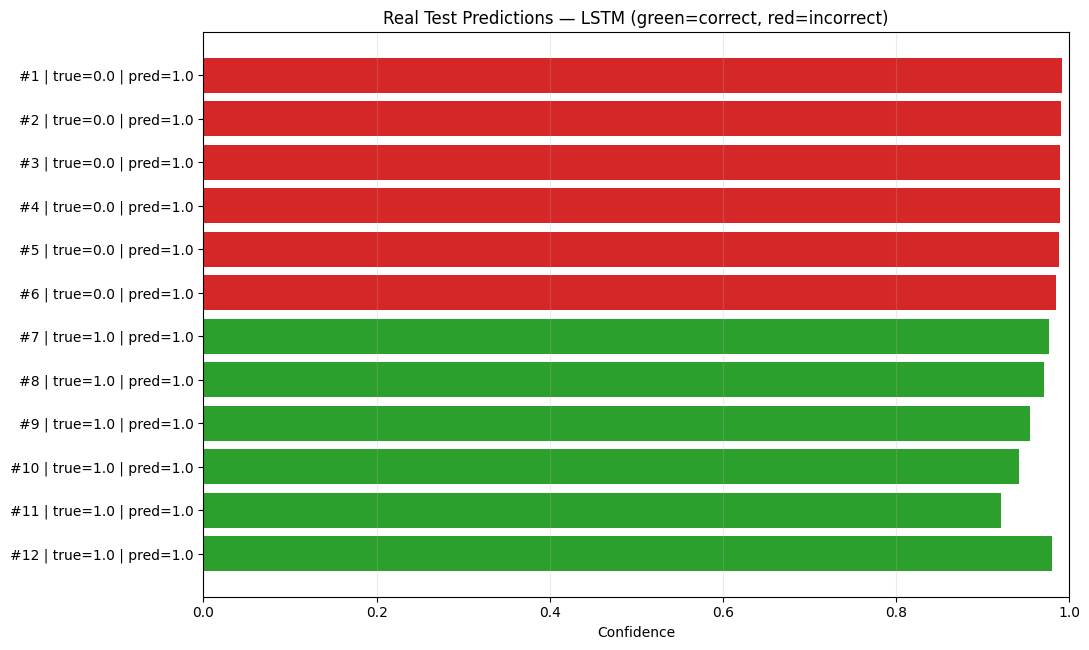

,original_text,true_label,predicted_label,confidence,correct
0,"Quán không gian chill, bánh mỳ nhân đầy thịt giòn rụm, nước sốt đặc biệt rất ngon. Nước rau má có nhiều loại để lựa chọn, rất ngon và mát. Giá cả phù hợp 🥰",0.0,1.0,0.9922,False
1,Hà Nội 1 chiều nắnggg hanh phờ cả người mà vẫn quyết định phi từ Mỹ Đình ra tận Lò Đúc chỉ vì quán kem này Đi xe bus khổ cực cam lai 😹😹😹 Ấy vậy mà tới nơi gọi đĩa kem hoa quả 2 đứa ăn no ứ bụngg luôn Quá là ngon bổ rẻ Hơi xa mà ăn ngon vẫn là chân áii Ưng tất ☺️☺️☺️☺️☺️,0.0,1.0,0.9913,False
2,"📌Gà không lối thoát - gọi ship tận nhà từ fb Thành Thuý foods - sđt 0978114912 (có ăn tại nhà hàng ở Ngõ 1 - 107B4 Nghĩa Tân)📌 chỉ tầm 30p là có đồ ăn đến nhà r (270k/con) Hôm nào nhà có khách mà lười ra đường thì gọi món này rất ổn nhá, nhưng ăn ở quá vẫn hơn, ăn nóng hổi, họ bày biện với cắt xôi riêng, gà riêng, ngon hơn :) Về nhà ko chuyên nghiệp tý nào nhưng đc cái gà rất ngon, ko bị bở, đậm đà. Xôi hơi mềm, đáng ra phải zòn thì ngon hơn, à thiếu cả vị nước cốt dừa ở xôi. Đồ chấm ở quán này chỉ là muối, tuỳ nơi có cả nước tương, hay tương ớt. Ăn được nhiều lắm, 3 4 người ăn ý, nói chung khá ngon. Vào fb của quán này còn nhiều món về gà hoặc xôi nhìn hấp dẫn lắm, nên thử. Gọi về họ cho cả cái hộp dày giữ nhiệt và bao tay nilon đỡ mỡ vì ăn món này xác định mỡ lắm (do xôi)",0.0,1.0,0.9901,False
3,"Đồ ăn ngon, nhân viên phục vụ nhanh, không gian đẹp, thoáng mát, quản lý hay đi hỏi khách dịch vụ như thế nào để cải thiện dịch vụ tốt hơn tạo cho khách hàng một cảm giác thoải mái thân thiện và gần gũi. Sẽ quay lại nhà hàng thường xuyên❤️❤️❤️❤️",0.0,1.0,0.9892,False
4,"Thấy mấy chị em oder ăn rồi post hình face làm mình nhìn thấy thèm thế. Hỏi địa chỉ ngay để tìm mua ăn. Lúc đầu cứ nghĩ sợ ăn ko ngon. Nhưng ai dè ngon ko tưởng được. Đủ các loại bánh và loại vị để chọn lựa. Các loại bánh ko chỉ bắt mắt mà còn ngon ko tưởng. Gây nghiện lắm các bạn ạ. Ăn xong chỉ muốn ăn nữa thôi. Shop bán hàng tư vấn, trả lời nhanh và nhiệt tình. Sẽ ủng hộ dài dài nha shop. # custard. phomai. dau. tra xanh. # bánh mì chesee # bánh cá 😍 🤤 😜❤️",0.0,1.0,0.9887,False
5,"Một tuần ngồi ở Dingtea Lạc Trung cũng phải vài lần. Quán tầng 2 trang trí đẹp, ấm cúng, bên ngoài ban công khá thoáng nhìn xuống đường, buổi tối có đèn lấp lánh lãng mạn phết. Nhân viên khá thân thiện và nhanh nhẹn, mình order xong lên ngồi khoảng 5p là có đồ. Ngoài trà sữa quán còn bán thêm cả đồ ăn vặt như kiểu bánh ngọt, bò khô các thứ các thứ nữa. Trà sữa Ô Long 30% Đường ĐỈNH, Nhài Sữa 30% Đường ĐỈNH, Bông lan trứng muối max ĐỈNH",0.0,1.0,0.9854,False
6,"Mình gọi xuất chả thêm và trà đá cốc lớn (trà đá ở đây khá là hợp với mình vì là vị trà xanh tươi chứ không phải vị trà khô) ăn khá ngon thịt mềm thơm, xém xém rất vừa miệng bát đĩa đổi mới nhìn rất xinh xắn và đẹp",1.0,1.0,0.9768,True
7,"Không gian quán khá yên tĩnh, có thể mời khách hàng, thiết đãi - điều đặc biệt quán còn có 1 sky bar view hồ gươm ngắm về đêm khá chill điểm cộng cho quán. Menu đa dạng từ cơm trưa, set tối tới list đồ uống. giá tầm trung và high đều có để lựa chọn",1.0,1.0,0.9714,True
8,"Đặt 8 suất cơm sườn sốt tiêu ôi ngon k cưỡng lại được. Đồ ăn ngon cơm mềm thịt thơm, giao hàng nhanh. Thích quá. Chắc chắn sẽ ủng hộ tiếp làn sau và sau nữa",1.0,1.0,0.9546,True
9,"Hàng ưa thích của mình vì ngon đồng đều & ship gần, mình ăn thường xuyên luôn. Bánh tráng trộn ko phải chuẩn kiểu SG dai ngọt khé cổ, mình thix vừa phải như này hơn, hợp khẩu vị miền Bắc, bánh tráng dính tí nhưng mềm ko quá dai, nhai ko đau răng 😂 topping cũng ok đầy đặn, nhiều xoài là mình thích vì đỡ ngán. Bánh cuộn thì cũng gọi là tạm ổn, sốt me hơi ngấy + nhạt và làm bánh bị dính, topping hơi ít đạm nhưg nói chung là ăn đc. Đồ ship thì lần sau shop nên để sốt riêng :(",1.0,1.0,0.9425,True


In [26]:
visualization_pool = predictions_df.copy()
visualization_pool["correct"] = (
    visualization_pool["true_label"] == visualization_pool["predicted_label"]
)

correct_pool = visualization_pool[visualization_pool["correct"]]
error_pool = visualization_pool[~visualization_pool["correct"]]
selected_parts = []

if not error_pool.empty:
    selected_parts.append(
        error_pool.sort_values("confidence", ascending=False).head(6)
    )
if not correct_pool.empty:
    selected_parts.append(
        correct_pool.sample(
            n=min(6, len(correct_pool)),
            random_state=SEED,
        )
    )

real_examples = (
    pd.concat(selected_parts, ignore_index=True)
    if selected_parts
    else visualization_pool.head(12).copy()
)
real_examples = real_examples.head(12).reset_index(drop=True)
real_examples["example"] = [
    f"#{index + 1} | true={row.true_label} | pred={row.predicted_label}"
    for index, row in real_examples.iterrows()
]

colors = real_examples["correct"].map(
    {True: "#2ca02c", False: "#d62728"}
).tolist()
fig, axis = plt.subplots(figsize=(11, max(5, 0.55 * len(real_examples))))
axis.barh(real_examples["example"], real_examples["confidence"], color=colors)
axis.set_xlim(0, 1)
axis.set_xlabel("Confidence")
axis.set_title(f"Real Test Predictions — {MODEL_TYPE.upper()} (green=correct, red=incorrect)")
axis.invert_yaxis()
axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    real_examples[
        ["original_text", "true_label", "predicted_label", "confidence", "correct"]
    ].style.format({"confidence": "{:.4f}"})
)

## 23. Summary

This notebook completed a leakage-safe Vietnamese sentiment classification workflow:

- Direct download of the public Kaggle dataset without a credential-upload step, plus automatic recursive extraction.
- Automatic file, column, and label discovery.
- Unicode-safe Vietnamese normalization and tokenization.
- Stratified splitting when possible and a training-only vocabulary.
- Configurable packed-sequence Vanilla RNN, GRU, or LSTM classification.
- Reproducible training with tqdm, gradient clipping, early stopping, and checkpointing.
- Multiclass evaluation, prediction inspection, and reusable inference.


## 24. Extended Practice and Alternative Datasets

Use a new notebook copy for each exercise and keep the original train/validation/test
separation. Start with `SAMPLE_LIMIT = 3000`, verify the pipeline, then switch it to
`None` for the final experiment.

### Core exercises

1. **Compare recurrent architectures.** Train RNN, GRU, and LSTM with the same seed,
   data split, vocabulary, and epoch budget. Report accuracy, macro-F1, training time,
   parameter count, and the most common error pair.
2. **Sequence-length ablation.** Try `MAX_SEQUENCE_LENGTH` values 40, 80, 160, and
   256. Plot macro-F1 and runtime against sequence length. Explain where truncation
   begins to hurt.
3. **Vocabulary ablation.** Compare word vocabularies of 5k, 15k, and 30k tokens.
   Record the `<UNK>` rate on validation and test data and relate it to macro-F1.
4. **Class imbalance.** Compare the current loss with class-weighted cross entropy.
   Include per-class recall and confusion matrices, not only overall accuracy.
5. **Error analysis dashboard.** Display the 20 highest-confidence mistakes and
   assign each to a manual category such as negation, mixed sentiment, slang,
   spelling noise, or insufficient context.

### Practice with other datasets

- [UIT Vietnamese Students' Feedback Corpus](https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback):
  adapt schema detection to three sentiment classes and compare student feedback
  with food-review language.
- [Vietnamese Sentiment Analysis (Kaggle)](https://www.kaggle.com/datasets/phuocthanhngo/vietnamese-sentiment-analysis):
  repeat the full pipeline on positive, negative, and neutral labels.
- [Synthetic Vietnamese Students' Feedback Corpus](https://www.kaggle.com/datasets/toreleon/synthetic-vietnamese-students-feedback-corpus):
  train on synthetic feedback and test on real UIT-VSFC feedback to measure domain
  shift.
- [IMDb](https://huggingface.co/datasets/stanfordnlp/imdb):
  test whether the same recurrent pipeline transfers to long English movie reviews.

### Challenge exercises

1. Add pretrained FastText embeddings and compare frozen versus fine-tuned vectors.
2. Add an attention layer over recurrent outputs and visualize attention weights for
   correctly and incorrectly classified reviews.
3. Run cross-domain evaluation: train on one Vietnamese review dataset and test on
   another without retraining. Quantify the performance drop.
4. Replace the recurrent encoder with a small Transformer while preserving the same
   split and evaluation code. Compare quality, speed, and memory usage fairly.